# 2D ERT processing and inversion with ResIPy
This tutorial performs data processing and ERT inversion with `ResIPy`

## 1. Initialize R2 and design the survey
First we need to import librarie and define paths, electrodes and geometry


In [37]:
datadir = '../data/fieldcamp2025/'
outputdir = '../figures/'
filename= '1'

from resipy import Project
from resipy import R2 # geophysics tools
import numpy as np # matrice operations 
import matplotlib.pyplot as plt

import ERTutils as utils

# Topography

In [38]:
# load dataset
k = R2()
k.createSurvey(datadir + filename+'.csv', ftype='Syscal')
k.importElec(datadir +'elecs.csv')
k.elec.head()

Working directory is: /home/alberto/anaconda3/envs/electro/lib/python3.11/site-packages/resipy
clearing dirname
filterData: 0 / 5547 quadrupoles removed.
5546/5547 reciprocal measurements found.
122 measurements error > 20 %


,label,x,y,z,buried,remote
0,1,0.0,0.0,349.4850,False,False
1,2,1.0,0.0,349.4753,False,False
2,3,2.0,0.0,349.4656,False,False
3,4,3.0,0.0,349.4559,False,False
4,5,4.0,0.0,349.4462,False,False


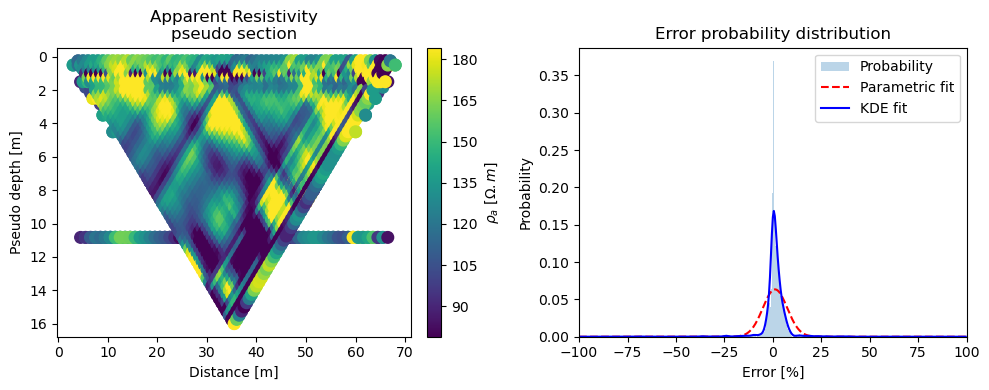

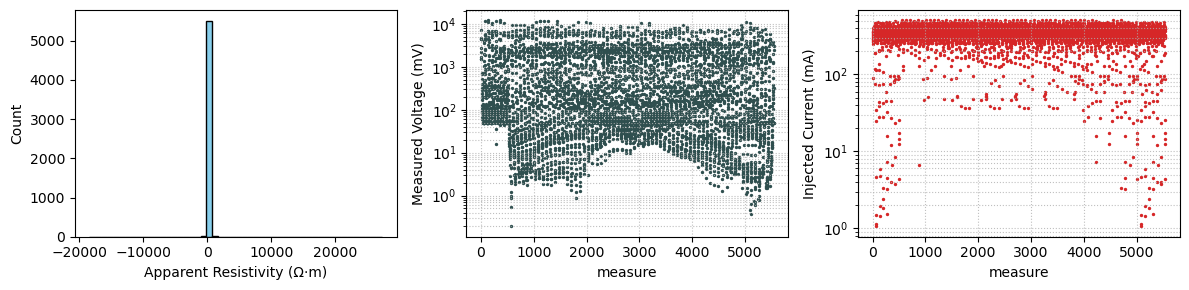

In [39]:
# plot pseudosection and error distribution
fig, ax = plt.subplots(1, 2, figsize=(10,4))
k.showPseudo(ax=ax[0])
k.showErrorDist(ax=ax[1])
fig.tight_layout()

df2 = k.surveys[0].df # access to the data
rhoa = df2["app"].values

utils.SurveyStats(df2)

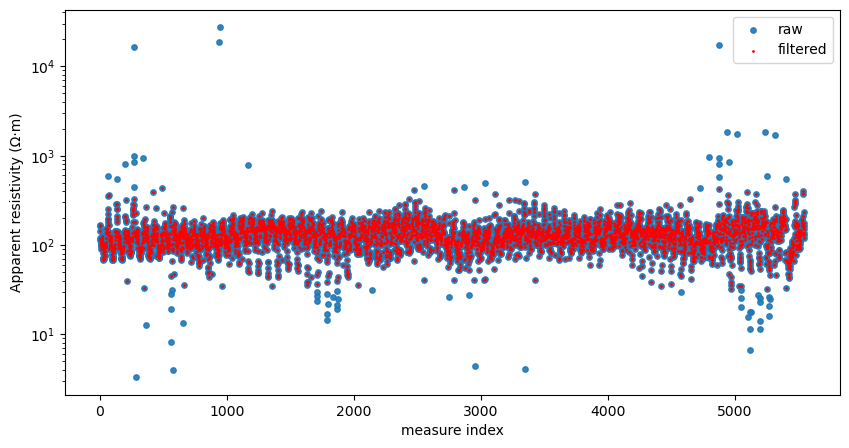

31.700763437032887 434.5964914011181


In [40]:
measure_idx = np.arange(len(rhoa))  # indice misura
vmin = np.percentile(rhoa, 1.5)
vmax = np.percentile(rhoa, 99.5)
# filtraggio
mask = np.isfinite(rhoa) & (rhoa > vmin) & (rhoa < vmax)
rhoa_filt = rhoa[mask]
measure_idx_filt = measure_idx[mask]

plt.figure(figsize=(10,5))
plt.scatter(measure_idx, rhoa, s=15, c="tab:blue", alpha=0.9, label="raw") # raw
plt.scatter(measure_idx_filt, rhoa_filt, s=1, c="red", alpha=1, label="filtered") # filt

plt.yscale("log")
plt.xlabel("measure index")
plt.ylabel("Apparent resistivity (Ω·m)")
plt.legend()
plt.show()

print(vmin, vmax)

filterData: 881 / 5547 quadrupoles removed.
removeUnpaired:filterData: 0 / 4666 quadrupoles removed.
filterData: 252 / 4666 quadrupoles removed.
252 measurements with greater than 10.0% reciprocal error removed!
37 measurements outside [20,450] removed!
Error model is R_err = 0.013 R_avg^0.617 (R^2 = 0.952)


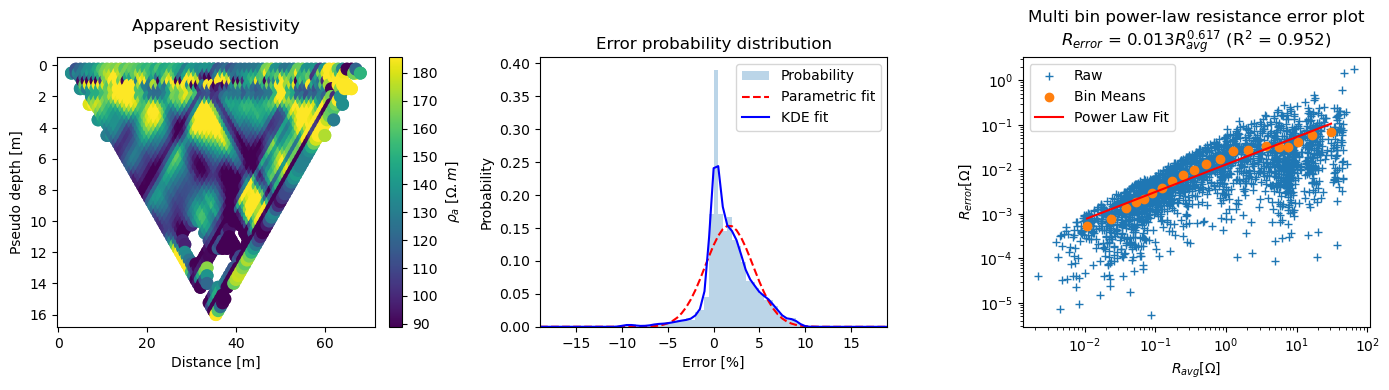

In [41]:
k.filterDummy()
k.filterUnpaired()
k.filterRecip(percent=10)
k.filterAppResist(vmin=20, vmax=450)

# ccheck
fig, ax = plt.subplots(1, 3, figsize=(14,4))
k.showPseudo(ax=ax[0])
k.showErrorDist(ax=ax[1])
k.fitErrorPwl(ax=ax[2])
fig.tight_layout()

#k.fitErrPwl()

Creating triangular mesh...done (4517 elements)


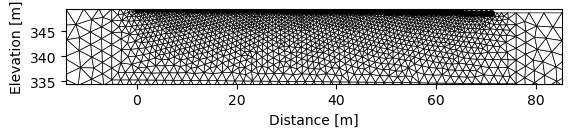

In [42]:
# import electrodes
n_elecs=72
dx=1
len_x=(n_elecs-1)*dx
z_doi=len_x/5

k.createMesh(typ='trian', cl=.5, cl_factor=5, fmd=z_doi
            )
k.showMesh()

In [45]:
k.param['data_type'] = 1 # using log of resistitivy
k.param['error_mod'] = 2
#k.param['err'] = True
k.param['a_wgt'] = 0.015
k.param['b_wgt'] = 0.1
k.invert()

#k.saveProject(ertdir + 'ert-line1.resipy')

Writing .in file and protocol.dat... done

--------------------- MAIN INVERSION ------------------


0120:fixme:ntdll:EtwEventSetInformation (deadbeef, 2, 0000000145007BE0, 43) stub




 >> R  2    R e s i s t i v i t y   I n v e r s i o n   v4.10 <<

 >> D a t e : 14 - 11 - 2025
 >> My beautiful survey                                                             
 >> I n v e r s e   S o l u t i o n   S e l e c t e d <<
 >> Determining storage needed for finite element conductance matrix
 >> Generating index array for finite element conductance matrix
 >> Reading start resistivity from res0.dat                      
 >> R e g u l a r i s e d   T y p e <<
 >>   L i n e a r    F i l t e r    <<
 >> L o g - D a t a   I n v e r s i o n <<
 >> N o r m a l   R e g u l a r i s a t i o n <<
 >> D a t a   w e i g h t s   w i l l   b e  m o d i f i e d <<


 Processing dataset   1


 Measurements read:  2188     Measurements rejected:     0
   Geometric mean of apparent resistivities:  0.26007E+03

 >> Total Memory required is:          0.082 Gb

   Iteration   1
     Initial RMS Misfit:         3.64       Number of data ignored:     0
     Alpha:          82.597   RMS Misfit:

All ok
0120:fixme:ver:GetCurrentPackageId (00007FFFFE1FEBA0 0000000000000000): stub


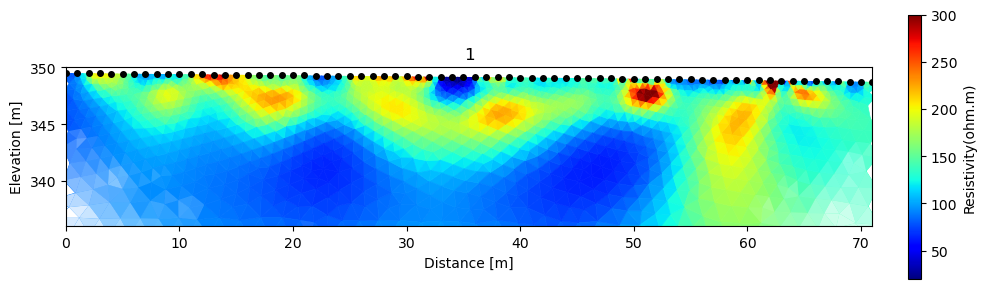

In [55]:
# plot the results
fig, ax = plt.subplots(figsize=(10,3), sharex=True)
k.showResults(index=0, ax=ax,
                 attr='Resistivity(ohm.m)', vmin=20, vmax=300,
                 #clipCorners=True,
                 #contour=True,
                 color_map='jet', sens=True
                )
ax.set_xlim(0, len_x)
ax.set_ylim(336, 350)
ax.set_title(filename)
fig.tight_layout()
fig.savefig(outputdir +filename +'_model.png', #transparent = True,
            dpi=200)